# CIFF MMC2 Paper Regression Test

This notebook implements the concatenated incoherent feed-forward (CIFF) model from `mmc2.pdf` using the Table S1 parameter values. It checks the paper-style habituation and recovery measurements, then runs the same model through the RL4CRN `habituation_hallmarks_mmc2` loss and rendering plots.

Two peak conventions are shown deliberately:

- **Paper comparison:** period-local maxima of the response trajectory, matching the reported `h_t` values in Figures 2 and 3.
- **RL4CRN MMC2 task rendering:** the current task cache and plots, useful for debugging what the search objective is evaluating.


In [1]:
import os
import sys
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-rl4crn')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from RL4CRN.utils.default_tasks.HabituationTaskKind import habituation_hallmarks_mmc2_metric
from RL4CRN.iocrns.iocrn import IOCRN

print('Python:', sys.version.split()[0])
print('CWD:', os.getcwd())


Python: 3.10.12
CWD: /local0/rossin/git/GenAI-Net


## 1) CIFF equations and Table S1 parameters

The state is `[I1, M1, R1, I2, M2, R2]`, with `R2` used as the response. The stimulus is a rectangular pulse `SQW(t)` with amplitude `A`, on-time `Ton`, and period `T`.


In [2]:
CIFF_TABLE_S1 = {
    'kIa1': 0.023,
    'kIi1': 34.44,
    'kMa1': 17.71,
    'kMi1': 0.0382,
    'kRa1': 57.92,
    'kRi1': 1.39,
    'K1': 0.000534,
    'kIa2': 0.0160,
    'kIi2': 14.3,
    'kMa2': 4.34,
    'kMi2': 0.00147,
    'kRa2': 26.2,
    'kRi2': 45.99,
    'K2': 0.791,
}

class CIFFPaperModel:
    def __init__(self, params=None, rtol=1e-7, atol=1e-9, max_step=0.02, gap_max_step=5.0):
        self.params = dict(CIFF_TABLE_S1 if params is None else params)
        self.rtol = float(rtol)
        self.atol = float(atol)
        self.max_step = float(max_step)
        self.gap_max_step = float(gap_max_step)
        self.species_labels = ['I1', 'M1', 'R1', 'I2', 'M2', 'R2']
        self.output_labels = ['R2']
        self.species_idx_dict = {name: i for i, name in enumerate(self.species_labels)}
        self.output_idx = np.asarray([self.species_idx_dict['R2']], dtype=int)
        self.num_species = len(self.species_labels)
        self.num_outputs = 1
        self.last_task_info = {}

    def rate_function(self, t, x, u):
        S = float(np.asarray(u, dtype=float).reshape(-1)[0])
        p = self.params
        I1, M1, R1, I2, M2, R2 = np.asarray(x, dtype=float)
        R1_safe = max(float(R1), 0.0)
        R2_safe = max(float(R2), 0.0)
        return np.asarray([
            S * p['kIa1'] * (1.0 - I1) - p['kIi1'] * I1,
            I1 * p['kMa1'] * (1.0 - M1) - p['kMi1'] * M1,
            I1 * p['kRa1'] * (1.0 - R1) - M1 * p['kRi1'] * R1_safe / (p['K1'] + R1_safe),
            R1 * p['kIa2'] * (1.0 - I2) - p['kIi2'] * I2,
            I2 * p['kMa2'] * (1.0 - M2) - p['kMi2'] * M2,
            I2 * p['kRa2'] * (1.0 - R2) - M2 * p['kRi2'] * R2_safe / (p['K2'] + R2_safe),
        ], dtype=float)

    def transient_response_piecewise(self, u_nested_list, x0_list, nested_time_horizon, LARGE_NUMBER=1e4, force=True):
        times = None
        trajectories = []
        outputs = []
        u_programs = u_nested_list
        if len(u_programs) == 1 and len(x0_list) > 1:
            u_programs = u_programs * len(x0_list)

        for scenario_idx, x0 in enumerate(x0_list):
            x = np.asarray(x0, dtype=float).reshape(self.num_species)
            u_steps = u_programs[min(scenario_idx, len(u_programs) - 1)]
            t_parts = []
            x_parts = []
            offset = 0.0
            for seg_idx, local_grid in enumerate(nested_time_horizon):
                local_grid = np.asarray(local_grid, dtype=float)
                duration = float(local_grid[-1])
                u = np.asarray(u_steps[seg_idx], dtype=float).reshape(-1)
                segment_max_step = self.gap_max_step if float(u[0]) == 0.0 and duration > 100.0 else self.max_step
                sol = solve_ivp(
                    lambda t, y: self.rate_function(t, y, u),
                    (0.0, duration),
                    x,
                    t_eval=local_grid,
                    method='RK45',
                    rtol=self.rtol,
                    atol=self.atol,
                    max_step=segment_max_step,
                )
                if not sol.success:
                    raise RuntimeError(sol.message)
                tt = offset + sol.t
                xx = sol.y
                if t_parts:
                    tt = tt[1:]
                    xx = xx[:, 1:]
                t_parts.append(tt)
                x_parts.append(xx)
                offset += duration
                x = sol.y[:, -1]
            t = np.concatenate(t_parts)
            x_mat = np.concatenate(x_parts, axis=1)
            if times is None:
                times = t
            trajectories.append(x_mat)
            outputs.append(x_mat[self.output_idx, :])
        return times, trajectories, outputs, None

# Reuse the existing RL4CRN hallmark rendering methods on this paper model adapter.
CIFFPaperModel.plot_habituation_hallmarks = IOCRN.plot_habituation_hallmarks
CIFFPaperModel.plot_habituation_hallmark_diagnostics = IOCRN.plot_habituation_hallmark_diagnostics

ciff = CIFFPaperModel()
pd.Series(CIFF_TABLE_S1, name='Table S1')


kIa1     0.023000
kIi1    34.440000
kMa1    17.710000
kMi1     0.038200
kRa1    57.920000
kRi1     1.390000
K1       0.000534
kIa2     0.016000
kIi2    14.300000
kMa2     4.340000
kMi2     0.001470
kRa2    26.200000
kRi2    45.990000
K2       0.791000
Name: Table S1, dtype: float64

## 2) Paper-style protocol measurements

The paper reports the CIFF performance in Figure 2B and Figure 3A. These helpers measure peaks as maxima over each full stimulus period; using only the on-window gives too-fast `h_t` for this model because the response peak can occur after the input pulse ends.


In [3]:
TON = 1.11
PAPER_REGIMES = pd.DataFrame([
    {'panel': 'Fig 2B frequency', 'A': 10.0, 'T': 25.0, 'Ton': TON, 'paper_ht': 25, 'paper_rt': 2063},
    {'panel': 'Fig 2B frequency', 'A': 10.0, 'T': 20.0, 'Ton': TON, 'paper_ht': 22, 'paper_rt': 1914},
    {'panel': 'Fig 2B frequency', 'A': 10.0, 'T': 15.0, 'Ton': TON, 'paper_ht': 14, 'paper_rt': 1549},
    {'panel': 'Fig 3A intensity', 'A': 20.0, 'T': 15.0, 'Ton': TON, 'paper_ht': 32, 'paper_rt': 2291},
    {'panel': 'Fig 3A intensity', 'A': 30.0, 'T': 15.0, 'Ton': TON, 'paper_ht': 40, 'paper_rt': 2600},
])


def simulate_rect_train(model, A, T, Ton, n_pulses, x0=None, gap_after=None, test_after_gap=False, points_per_time=20):
    x0 = np.zeros(model.num_species, dtype=float) if x0 is None else np.asarray(x0, dtype=float)
    durations = []
    u_steps = []
    segment_types = []
    for _ in range(int(n_pulses)):
        durations.extend([float(Ton), float(T - Ton)])
        u_steps.extend([np.asarray([A], dtype=float), np.asarray([0.0], dtype=float)])
        segment_types.extend(['on', 'off'])
    if gap_after is not None:
        durations.append(float(gap_after))
        u_steps.append(np.asarray([0.0], dtype=float))
        segment_types.append('gap')
        if test_after_gap:
            durations.extend([float(Ton), float(T - Ton)])
            u_steps.extend([np.asarray([A], dtype=float), np.asarray([0.0], dtype=float)])
            segment_types.extend(['on', 'off'])
    nested_time = []
    for d, u, typ in zip(durations, u_steps, segment_types):
        if typ == 'gap' and float(u[0]) == 0.0 and float(d) > 10.0:
            n_points = max(3, min(200, int(np.ceil(float(d) / 5.0)) + 1))
        else:
            n_points = max(3, int(np.ceil(float(d) * points_per_time)) + 1)
        nested_time.append(np.linspace(0.0, d, n_points, dtype=float))
    t, xs, ys, _ = model.transient_response_piecewise([u_steps], [x0], nested_time, LARGE_NUMBER=1e6)
    intervals = []
    offset = 0.0
    for d in durations:
        intervals.append((offset, offset + float(d)))
        offset += float(d)
    return {
        'time': t,
        'states': xs[0],
        'response': ys[0][0],
        'intervals': intervals,
        'segment_types': segment_types,
        'u_steps': u_steps,
    }


def period_peaks(run, T, n_pulses):
    t = run['time']
    y = run['response']
    peaks = []
    troughs = []
    for i in range(int(n_pulses)):
        start = i * float(T)
        end = (i + 1) * float(T)
        mask = (t >= start) & (t <= end)
        peaks.append(float(np.max(y[mask])))
        troughs.append(float(np.min(y[mask])))
    return np.asarray(peaks), np.asarray(troughs)


def paper_habituation_time(peaks, tolerance=0.01):
    for i in range(len(peaks) - 1):
        rel_drop = (float(peaks[i]) - float(peaks[i + 1])) / max(float(peaks[i]), 1e-12)
        if rel_drop >= 0.0 and rel_drop < float(tolerance):
            return i + 1
    return np.inf


def test_peak_after_gap(model, A, T, Ton, train_pulses, gap):
    run = simulate_rect_train(model, A, T, Ton, train_pulses, gap_after=gap, test_after_gap=True)
    peaks, _ = period_peaks(run, T, train_pulses)
    test_start = train_pulses * T + float(gap)
    test_end = test_start + float(T)
    mask = (run['time'] >= test_start) & (run['time'] <= test_end)
    return float(np.max(run['response'][mask])), peaks, run


def paper_recovery_time(model, A, T, Ton, train_pulses, recovery_tol=0.05, max_gap=10000.0, depth=16):
    first_run = simulate_rect_train(model, A, T, Ton, train_pulses)
    first_peak = float(period_peaks(first_run, T, train_pulses)[0][0])

    def recovered(gap):
        test_peak, _, run = test_peak_after_gap(model, A, T, Ton, train_pulses, gap)
        rel = abs(test_peak - first_peak) / max(abs(first_peak), 1e-12)
        return rel <= recovery_tol, rel, test_peak, run

    ok, rel, peak, best_run = recovered(max_gap)
    if not ok:
        return np.inf, rel, peak, best_run
    lo, hi = 0.0, float(max_gap)
    best = (hi, rel, peak, best_run)
    for _ in range(int(depth)):
        mid = 0.5 * (lo + hi)
        ok, rel, peak, run = recovered(mid)
        if ok:
            hi = mid
            best = (hi, rel, peak, run)
        else:
            lo = mid
    return best


In [4]:
# This cell takes a little time because it performs the recovery binary searches.
# Increase rt_depth for tighter agreement with the paper; 14-16 is usually enough for a notebook check.
rt_depth = 14
rows = []
for _, row in PAPER_REGIMES.iterrows():
    A = float(row['A'])
    T = float(row['T'])
    Ton = float(row['Ton'])
    train = simulate_rect_train(ciff, A, T, Ton, 70)
    peaks, troughs = period_peaks(train, T, 70)
    ht = paper_habituation_time(peaks)
    train_pulses_for_rt = int(ht) + 1
    rt, rt_rel, rt_peak, _ = paper_recovery_time(
        ciff,
        A,
        T,
        Ton,
        train_pulses_for_rt,
        max_gap=10000.0,
        depth=rt_depth,
    )
    rows.append({
        **row.to_dict(),
        'computed_ht': int(ht) if np.isfinite(ht) else np.inf,
        'computed_rt': rt,
        'rt_rel_error': rt_rel,
        'ht_delta': (int(ht) - int(row['paper_ht'])) if np.isfinite(ht) else np.inf,
        'rt_delta': rt - float(row['paper_rt']),
    })

paper_check = pd.DataFrame(rows)
paper_check['ht_ok_within_1_stimulus'] = paper_check['ht_delta'].abs() <= 1
paper_check['rt_ok_within_10pct'] = paper_check['rt_delta'].abs() <= 0.10 * paper_check['paper_rt']
paper_check


,panel,A,T,Ton,paper_ht,paper_rt,computed_ht,computed_rt,rt_rel_error,ht_delta,rt_delta,ht_ok_within_1_stimulus,rt_ok_within_10pct
0,Fig 2B frequency,10.0,25.0,1.11,25,2063,25,2090.454102,0.049975,0,27.454102,True,True
1,Fig 2B frequency,10.0,20.0,1.11,22,1914,22,1947.631836,0.049984,0,33.631836,True,True
2,Fig 2B frequency,10.0,15.0,1.11,14,1549,14,1590.576172,0.049980,0,41.576172,True,True
3,Fig 3A intensity,20.0,15.0,1.11,32,2291,33,2330.322266,0.049976,1,39.322266,True,True
4,Fig 3A intensity,30.0,15.0,1.11,40,2600,41,2630.004883,0.049994,1,30.004883,True,True


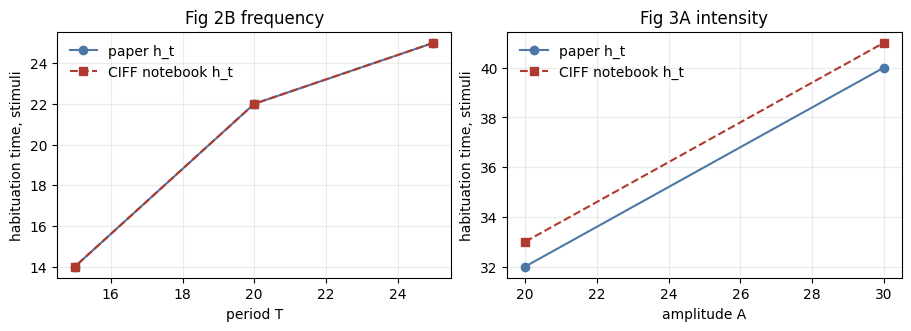

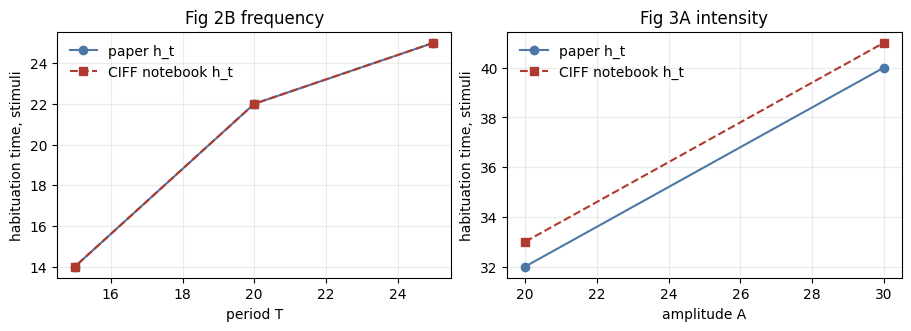

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), constrained_layout=True)
for panel, group in paper_check.groupby('panel'):
    ax = axes[0] if 'frequency' in panel else axes[1]
    x = group['T'] if 'frequency' in panel else group['A']
    ax.plot(x, group['paper_ht'], 'o-', label='paper h_t', color='#4C78A8')
    ax.plot(x, group['computed_ht'], 's--', label='CIFF notebook h_t', color='#B03A2E')
    ax.set_title(panel)
    ax.set_xlabel('period T' if 'frequency' in panel else 'amplitude A')
    ax.set_ylabel('habituation time, stimuli')
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
fig


## 3) Run the CIFF model through the RL4CRN MMC2 loss and renderer

This uses the same `habituation_hallmarks_mmc2_metric` and plotting methods as app 13. The loss may be stricter than the paper comparison above, because this repo version additionally enforces hard feasibility gates for missing habituation times and unstable trajectories.


In [6]:
mmc2_kwargs = dict(
    crn=ciff,
    u_list_local=[np.asarray([10.0], dtype=np.float32)],
    x0_list=[np.zeros(ciff.num_species, dtype=float)],
    pulse_shapes=[(TON, 25.0 - TON), (TON, 20.0 - TON), (TON, 15.0 - TON)],
    reference_pulse_shape_index=2,
    n_repeats_pre=50,
    n_repeats_post=50,
    gap_time=2000.0,
    n_t=2500,
    min_peak=1e-5,
    max_peak=1.0,
    LARGE_NUMBER=1e4,
    eps_h=0.01,
    eps_subliminal=0.005,
    recovery_tol=0.05,
    rt_search_depth=10,
    rt_max_gap=4000.0,
    potentiation_gap_fraction=0.5,
    intensity_values=[1.0, 2.0, 3.0],
    delta_p_max=0.5,
    monotone_drop_tol=1e-4,
    i_max=2,
    n_post_min=2,
    delta_min=0.2,
    delta_t=0.05,
    trough_thr=0.6,
    trough_tail=0.02,
    trough_count_thr=0.10,
    trough_count_max=5,
)

loss, hallmark_info = habituation_hallmarks_mmc2_metric(**mmc2_kwargs)
ciff.last_task_info = {
    'reward': float(loss),
    'reward type': 'habituation_hallmarks_mmc2',
    'hallmark_info': hallmark_info,
    'hallmark_runs': hallmark_info.get('hallmark_runs', []),
    'component_losses': hallmark_info.get('component_losses', {}),
    'type': 'transient response',
}
print('MMC2 loss:', loss)
print('Strict failures:', hallmark_info.get('strict_failures'))
print('Recovery rt:', hallmark_info.get('rt'), 'strict rt:', hallmark_info.get('rt_strict'))
print('Components:')
for name, value in ciff.last_task_info['component_losses'].items():
    print(f'  Component: {name}: {value:.6g}')


MMC2 loss: 0.0
Strict failures: []
Recovery rt: 1558.59375 strict rt: 1875.0
Components:
  Component: habituation_time: 0
  Component: recovery_time: 0
  Component: potentiation: 0
  Component: frequency_sensitivity: 0
  Component: intensity_sensitivity: 0
  Component: subliminal_accumulation: 0
  Component: valid_early_maximum: 0
  Component: valid_first_drop: 0
  Component: valid_high_trough_count: 0
  Component: valid_min_peak: 0
  Component: valid_monotone_tail: 0
  Component: valid_peak_trough_separation: 0
  Component: valid_post_count: 0
  Component: valid_response_amplitude: 0
  Component: valid_response_upper_bound: 0
  Component: valid_tail_trough: 0
  Component: valid_trough_bound: 0
  Component: trajectory_stability: 0
  Component: strict_feasibility: 0


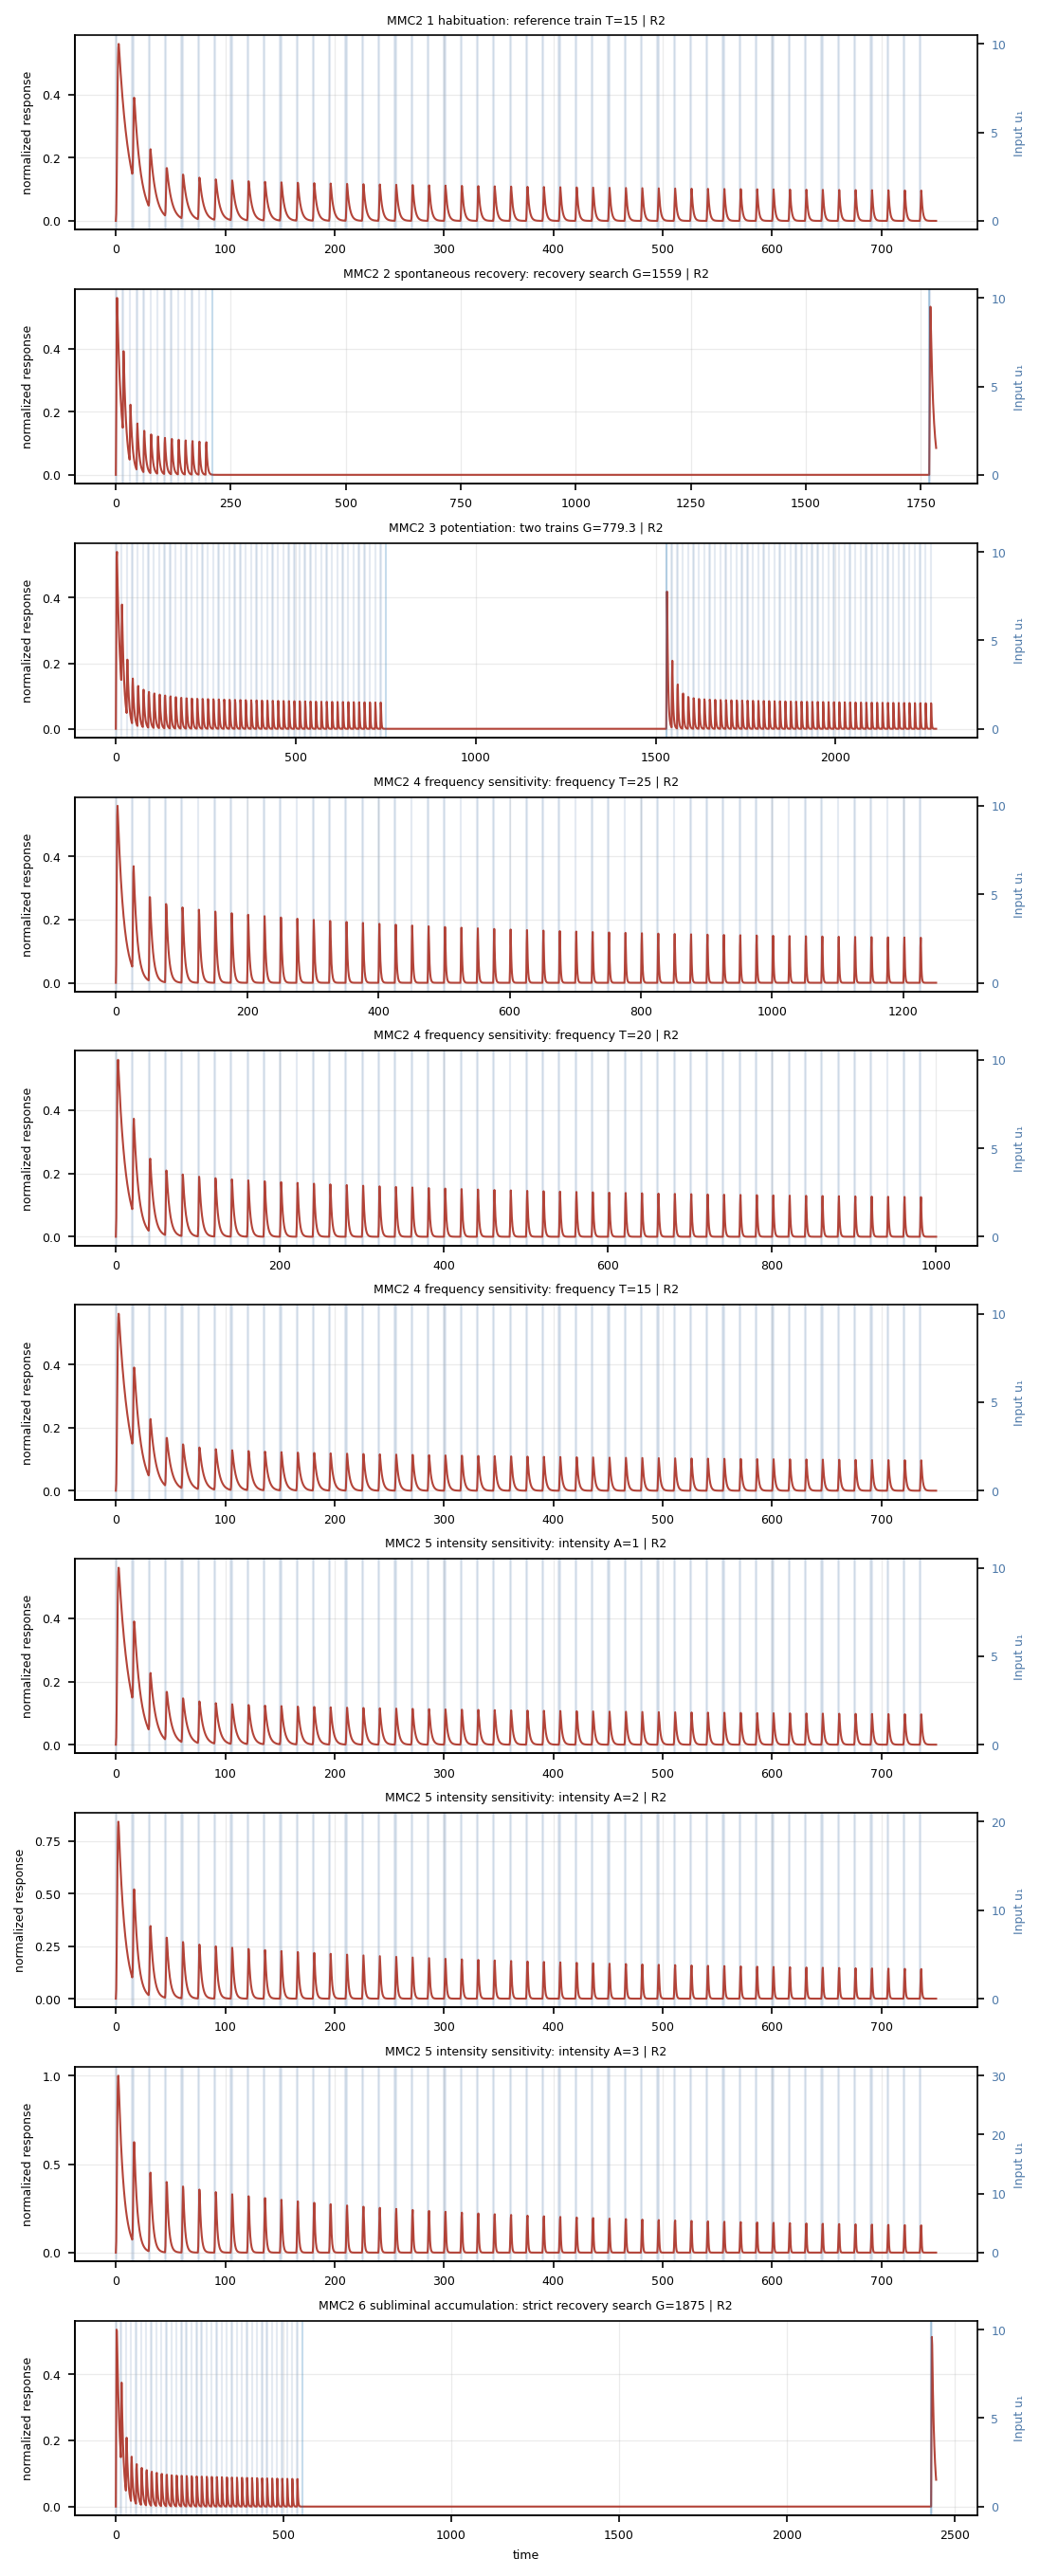

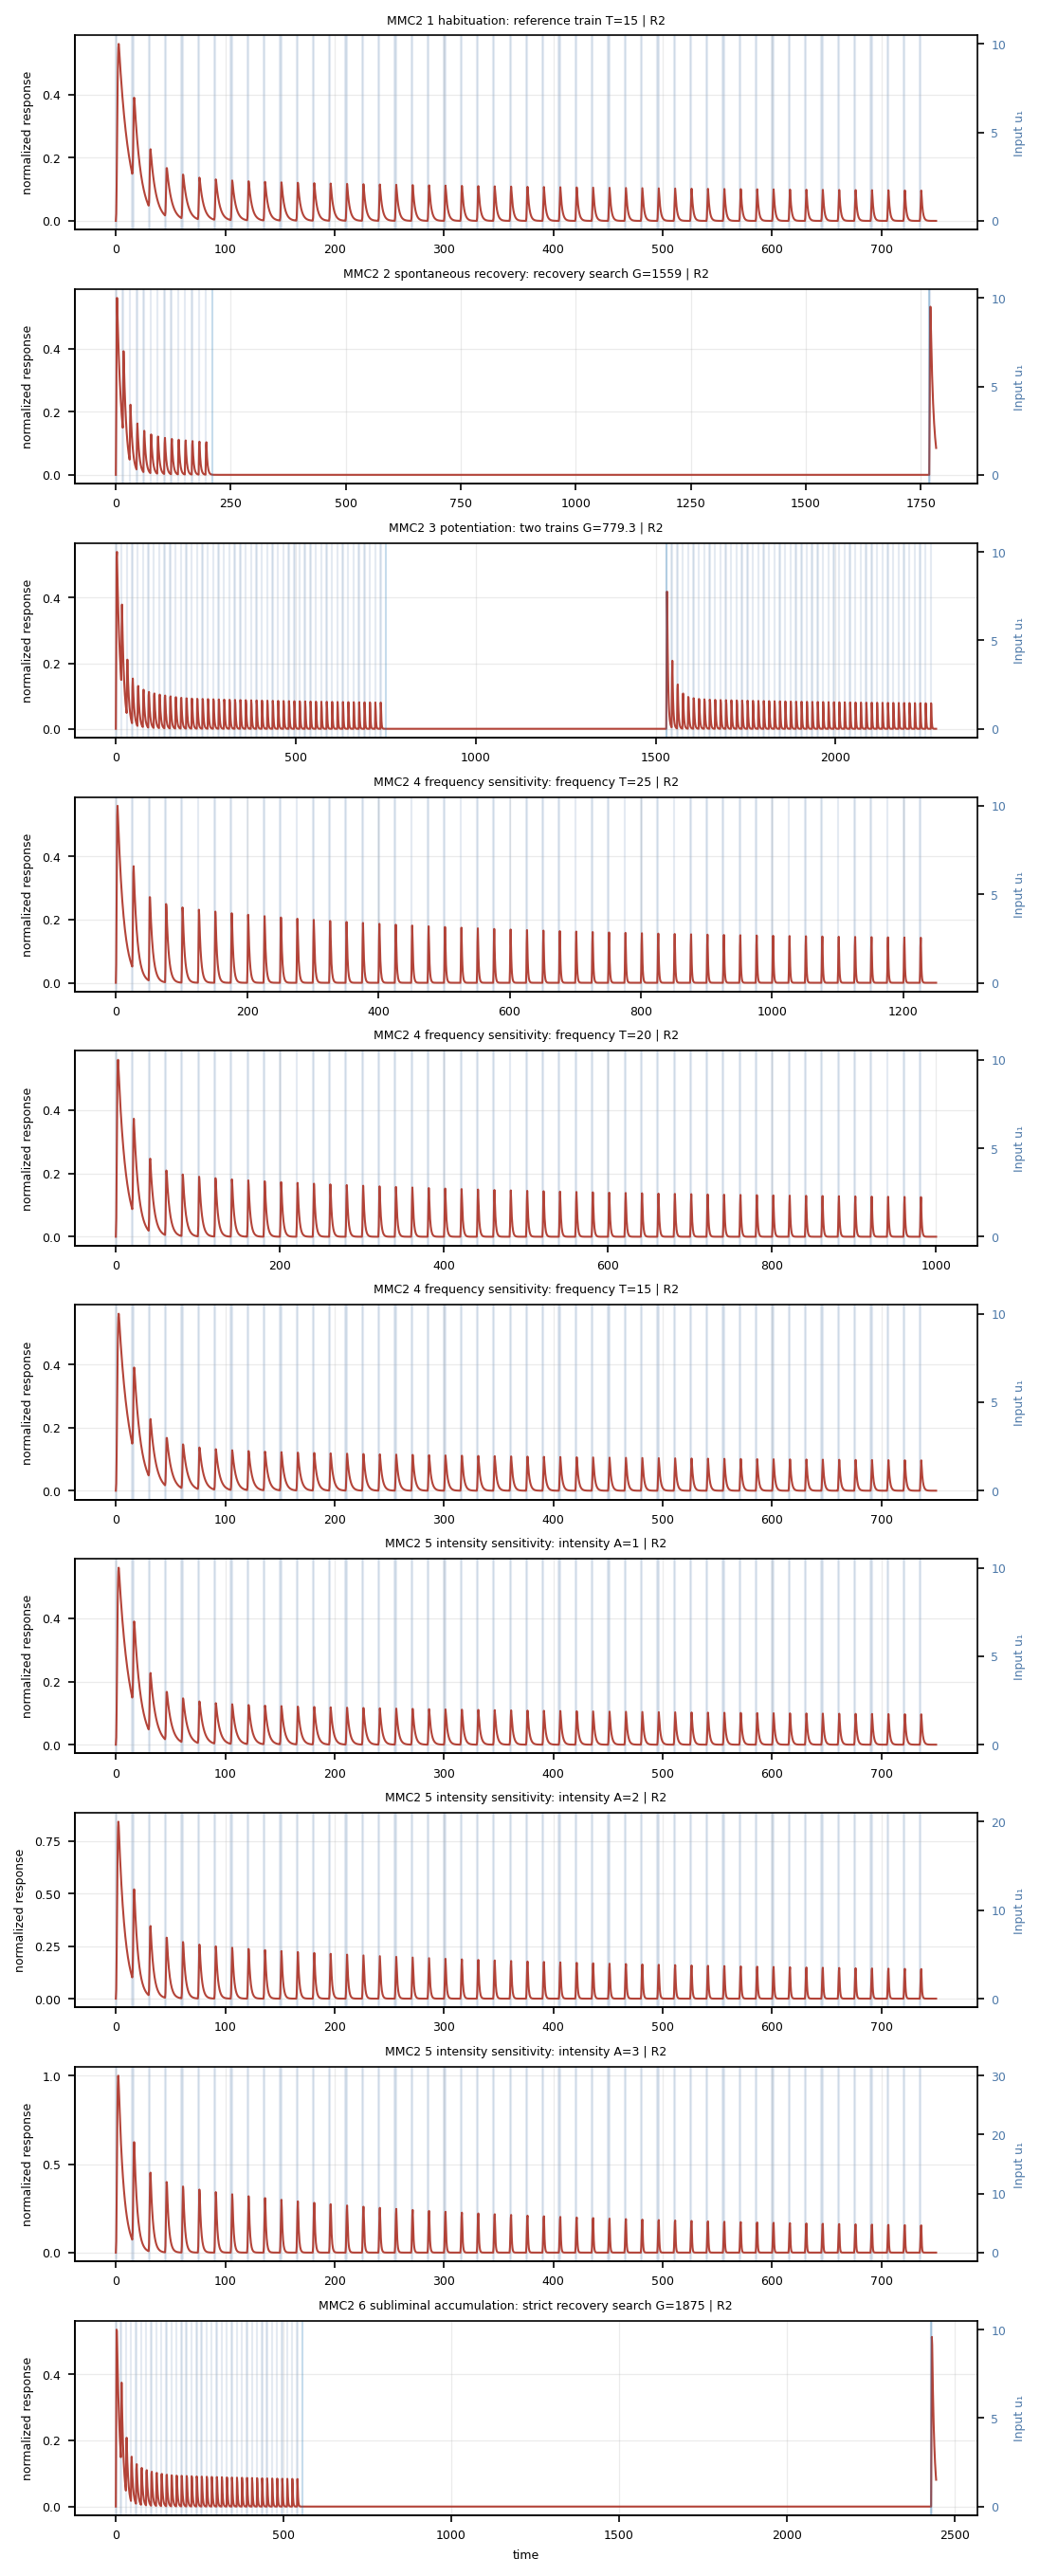

In [7]:
mmc2_plot_cfg = {
    'figsize': (7.2, 18),
    'alpha': 0.95,
    'xlabel': 'time',
    'ylabel': 'normalized response',
}
fig, axes = ciff.plot_habituation_hallmarks(
    normalize=True,
    input_color='#4C78A8',
    trj_color='#B03A2E',
    show_memory_species=False,
    plot_cfg=mmc2_plot_cfg,
)
fig


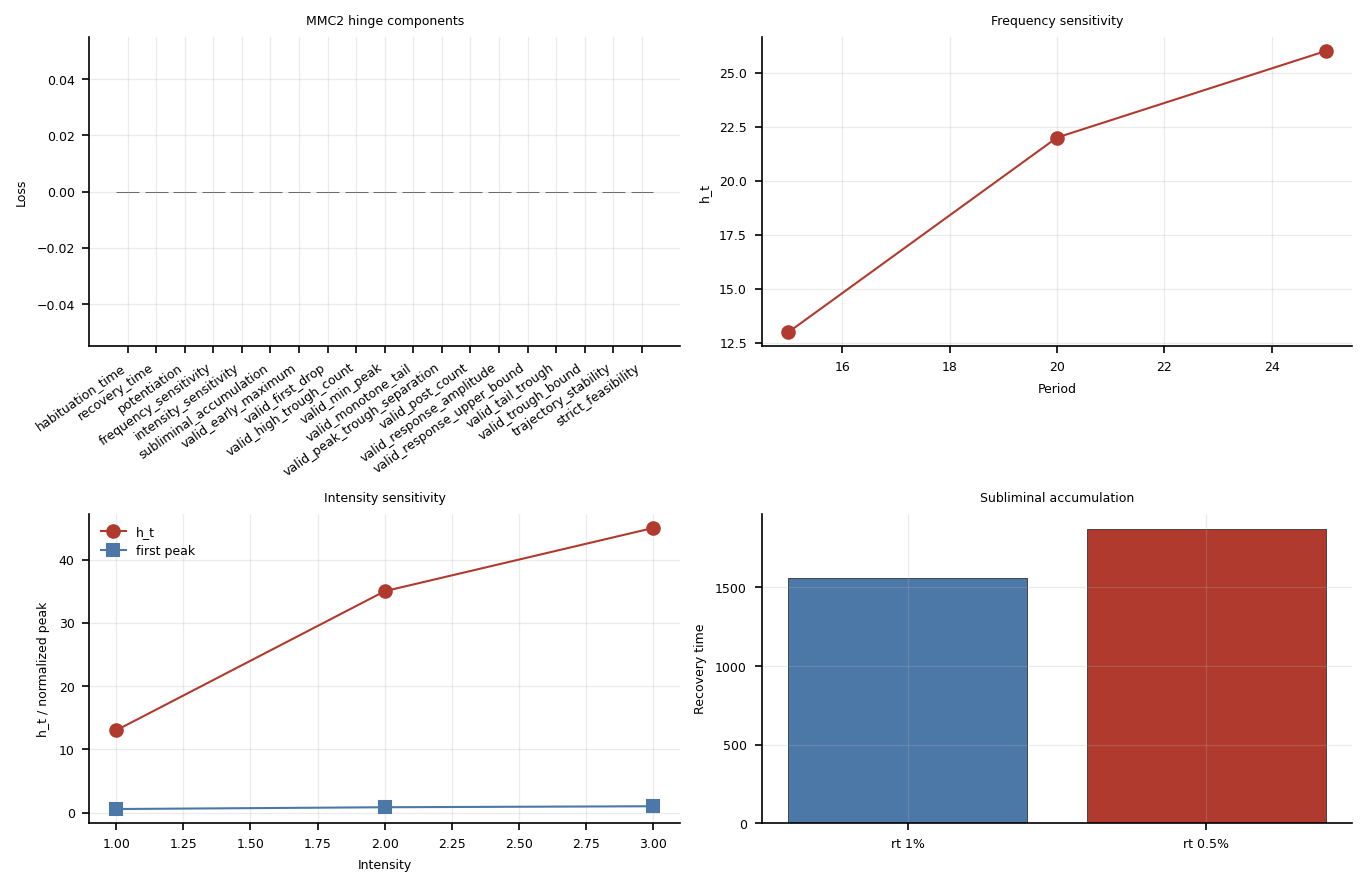

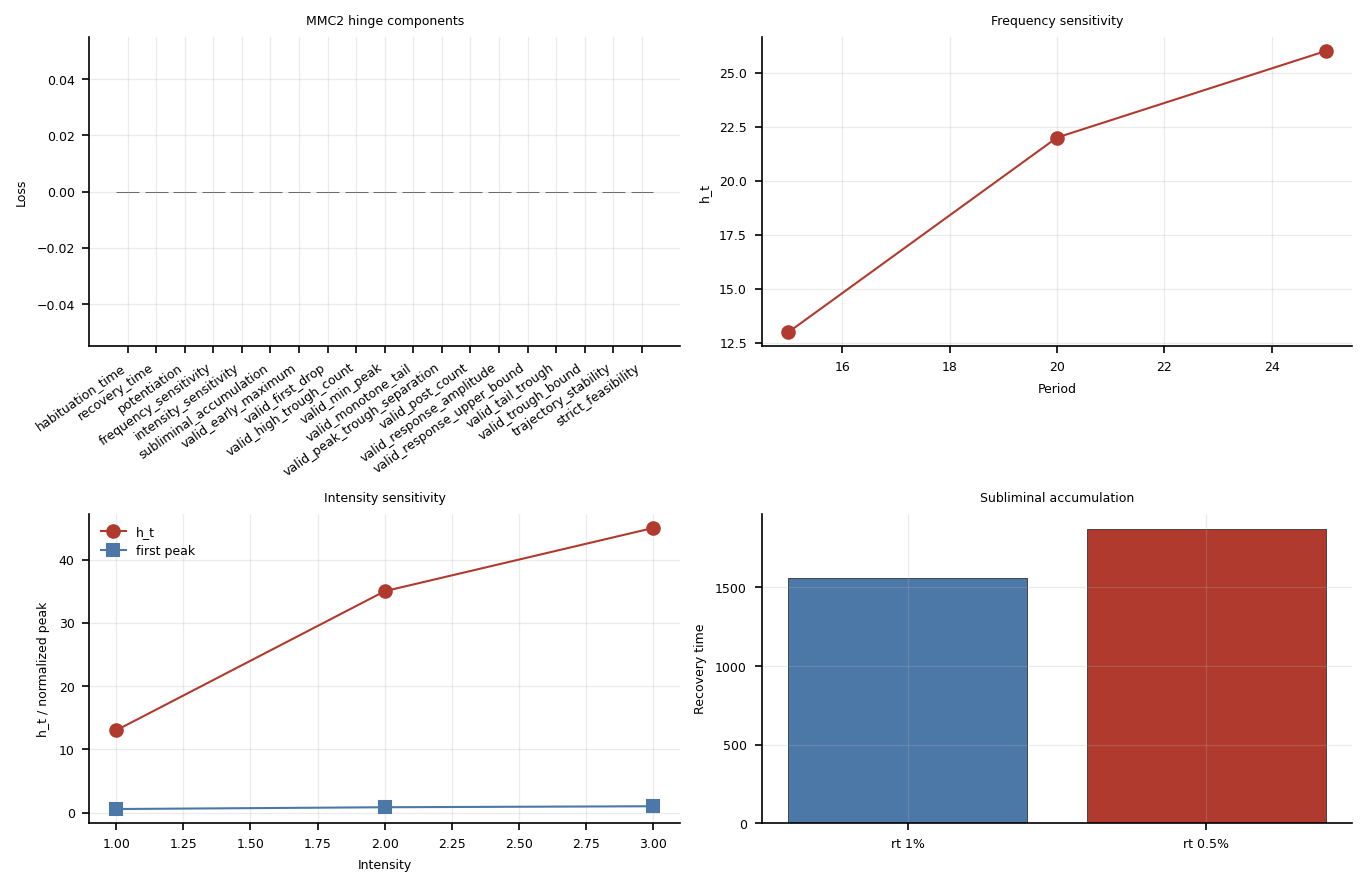

In [8]:
fig_diag, axes_diag = ciff.plot_habituation_hallmark_diagnostics(
    plot_cfg={'figsize': (9, 5.8)},
)
fig_diag


## 4) Optional: save figures

The outputs are saved under `comparisons/habituation_mmc2/figures` so the plots can be compared with future search outputs.


In [9]:
out_dir = 'comparisons/habituation_mmc2/figures'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(os.path.join(out_dir, 'ciff_table_s1_mmc2_render.png'), dpi=180, bbox_inches='tight')
fig_diag.savefig(os.path.join(out_dir, 'ciff_table_s1_mmc2_diagnostics.png'), dpi=180, bbox_inches='tight')
paper_check.to_csv(os.path.join(out_dir, 'ciff_table_s1_paper_check.csv'), index=False)
print('saved to', out_dir)


saved to comparisons/habituation_mmc2/figures
